In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "EMG_data_for_gestures-master"

print(DATA_DIR)
print(list(DATA_DIR.iterdir())[:5])


..\data\EMG_data_for_gestures-master
[WindowsPath('../data/EMG_data_for_gestures-master/01'), WindowsPath('../data/EMG_data_for_gestures-master/02'), WindowsPath('../data/EMG_data_for_gestures-master/03'), WindowsPath('../data/EMG_data_for_gestures-master/04'), WindowsPath('../data/EMG_data_for_gestures-master/05')]


In [33]:
subject_dir = DATA_DIR / "01"
files = sorted(subject_dir.glob("*.txt"))

print(files)


[WindowsPath('../data/EMG_data_for_gestures-master/01/1_raw_data_13-12_22.03.16.txt'), WindowsPath('../data/EMG_data_for_gestures-master/01/2_raw_data_13-13_22.03.16.txt')]


In [34]:
# Load one EMG file
file_path = files[0]
print("Loading:", file_path.name)

df = pd.read_csv(file_path, sep="\t", header=None)
df.head()

Loading: 1_raw_data_13-12_22.03.16.txt


,0,1,2,3,4,5,6,7,8,9
0,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
1,1,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
2,5,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
3,6,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0
4,7,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0


In [35]:
print (df.shape)


(63197, 10)


In [36]:
df.columns = (
    ["time"] +
    [f"ch{i}" for i in range(1, 9)] +
    ["label"]
)
df.head()


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label
0,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
1,1,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
2,5,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
3,6,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0
4,7,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0


In [37]:
df["label"].unique()


array(['class', '0', '1', '2', '3', '4', '5', '6'], dtype=object)

In [38]:
df["label"].value_counts().sort_index()


label
0        41272
1         3780
2         3525
3         3816
4         3441
5         3615
6         3747
class        1
Name: count, dtype: int64

<Axes: title={'center': 'Gesture class distribution (Subject 01)'}, xlabel='label'>

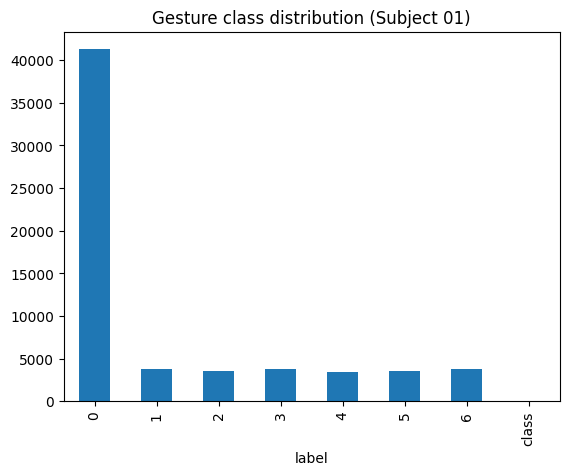

In [39]:
df["label"].value_counts().sort_index().plot(
    kind="bar",
    title="Gesture class distribution (Subject 01)"
)


In [40]:
# Remove the bad header row
# we have bad label inside our rows must be removed
df = df[df["label"] != "class"]

# Convert label column to integer
df["label"] = df["label"].astype(int)

# Verify
df["label"].unique(), df["label"].value_counts().sort_index()


(array([0, 1, 2, 3, 4, 5, 6]),
 label
 0    41272
 1     3780
 2     3525
 3     3816
 4     3441
 5     3615
 6     3747
 Name: count, dtype: int64)

In [41]:
df = df[df["label"] != "class"]
df["label"] = df["label"].astype(int)


In [42]:
# EMG channel column names
emg_cols = [f"ch{i}" for i in range(1, 9)]

# Convert EMG channels to numeric
for col in emg_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [43]:
df = df.dropna(subset=emg_cols)


In [44]:
import numpy as np

# EMG channel columns
emg_cols = [f"ch{i}" for i in range(1, 9)]

# Compute RMS across channels per sample block
# (simple proxy: RMS across channels at each time)
df["rms"] = np.sqrt((df[emg_cols] ** 2).mean(axis=1))


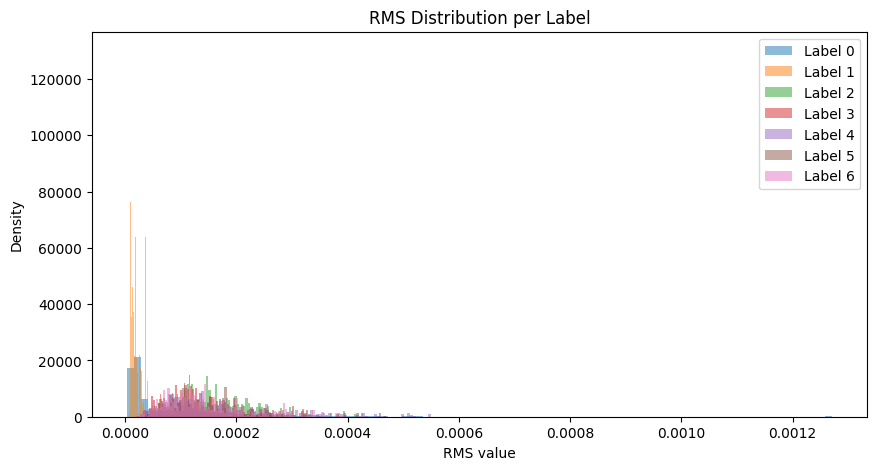

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for label in sorted(df["label"].unique()):
    rms_vals = df[df["label"] == label]["rms"]
    plt.hist(rms_vals, bins=100, alpha=0.5, label=f"Label {label}", density=True)

plt.title("RMS Distribution per Label")
plt.xlabel("RMS value")
plt.ylabel("Density")
plt.legend()
plt.show()


From this plot we can say that the thin yellow lines which is nearer to zero is rest 
and can assume remaining are the other hand movements


In [46]:
df.groupby("label")["rms"].agg(["mean", "std", "min", "max"])


,mean,std,min,max
label,,,,
0,0.000088,0.000117,0.000004,0.001270
1,0.000020,0.000008,0.000006,0.000052
2,0.000173,0.000066,0.000036,0.000427
3,0.000128,0.000059,0.000022,0.000329
4,0.000171,0.000106,0.000027,0.000572
5,0.000156,0.000080,0.000034,0.000483
6,0.000146,0.000075,0.000023,0.000430


label having least mean is rest as it has lease signal

there for we confirm that label one is rest which is yellow colour in the above plot


In [47]:
def map_to_2class(label):
    if label == 1:
        return "Rest"
    else:
        return "Other"

df["label_2c"] = df["label"].apply(map_to_2class)

df[["label", "label_2c"]].head()


,label,label_2c
1,0,Other
2,0,Other
3,0,Other
4,0,Other
5,0,Other


In [48]:
df["label_2c"].value_counts().sort_index()


label_2c
Other    59416
Rest      3780
Name: count, dtype: int64

In [49]:
# Windowing parameters
SAMPLING_RATE = 1000  # Hz
WINDOW_MS = 250       # milliseconds
WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_MS / 1000)
STEP_SIZE = WINDOW_SIZE // 4  # 50% overlap

WINDOW_SIZE, STEP_SIZE


(250, 62)

|----- window 1 -----|

        |----- window 2 -----|


we using this operlap to prevent data leakage at window end


In [50]:
# Map original labels to 2 classes (numeric)
# 0 = Rest, 1 = Other
def map_to_2class_numeric(label):
    return 0 if label == 1 else 1

df["label_2c_num"] = df["label"].apply(map_to_2class_numeric)

df[["label", "label_2c_num"]].head()


,label,label_2c_num
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1


In [51]:
import numpy as np

def create_windows_2c(df, subject_id):
    X, y, subjects = [], [], []

    data = df[emg_cols].values
    labels = df["label_2c_num"].values

    for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        end = start + WINDOW_SIZE

        window_data = data[start:end]
        window_labels = labels[start:end]

        # Majority vote for window label
        label = np.bincount(window_labels).argmax()

        X.append(window_data)
        y.append(label)
        subjects.append(subject_id)

    return np.array(X), np.array(y), np.array(subjects)


In [52]:
# Example sanity check with one subject
subject_id = 1
X_1, y_1, s_1 = create_windows_2c(df, subject_id)

X_1.shape, y_1.shape, np.unique(y_1, return_counts=True)


((1016, 250, 8), (1016,), (array([0, 1]), array([ 60, 956])))

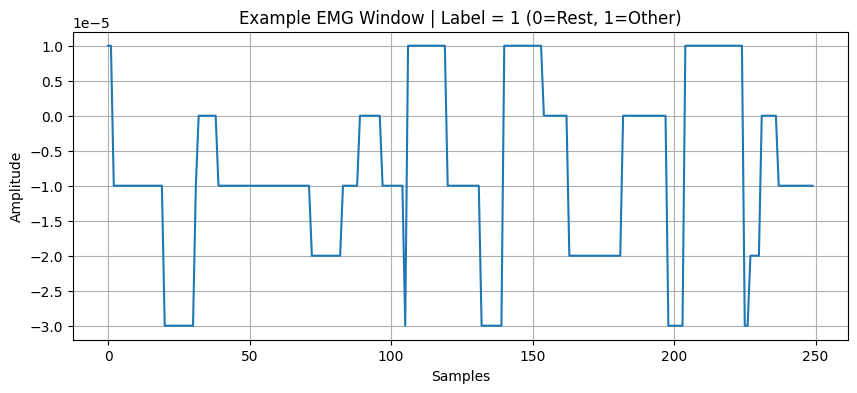

In [53]:
# visual check of one window
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(X_1[0][:, 0])  # Channel 1
plt.title(f"Example EMG Window | Label = {y_1[0]} (0=Rest, 1=Other)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


EMG window plot

The plot shows:

Low-amplitude EMG

Burst-like changes

No flatlines

No obvious artifacts

This confirms:
✔ Correct slicing
✔ No label misalignment
✔ EMG signal integrity preserved

In [54]:
from pathlib import Path

X_all = []
y_all = []
subjects_all = []

DATA_DIR = Path("..") / "data" / "EMG_data_for_gestures-master"

for subject_folder in sorted(DATA_DIR.iterdir()):
    if not subject_folder.is_dir():
        continue

    subject_id = int(subject_folder.name)

    for file_path in subject_folder.glob("*.txt"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            header=None,
            low_memory=False
        )

        # Assign column names
        df.columns = (
            ["time"] +
            [f"ch{i}" for i in range(1, 9)] +
            ["label"]
        )

        # Remove header rows if present
        df = df[df["label"] != "class"]

        # Convert label to numeric safely
        df["label"] = pd.to_numeric(df["label"], errors="coerce")
        df = df.dropna(subset=["label"])
        df["label"] = df["label"].astype(int)

        # Convert EMG channels to numeric
        for col in emg_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(subset=emg_cols)

        # Create 2-class label
        df["label_2c_num"] = df["label"].apply(map_to_2class_numeric)

        # Windowing
        X, y, s = create_windows_2c(df, subject_id)

        if len(X) > 0:
            X_all.append(X)
            y_all.append(y)
            subjects_all.append(s)
X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
subjects_all = np.concatenate(subjects_all)

X_all.shape, y_all.shape, subjects_all.shape



((68099, 250, 8), (68099,), (68099,))

In [55]:
# Check labels
print(np.unique(y_all, return_counts=True))
np.unique(subjects_all).shape

(array([0, 1]), array([ 4025, 64074]))


(36,)

In [56]:
from sklearn.model_selection import train_test_split
import numpy as np

# Unique subject IDs
unique_subjects = np.unique(subjects_all)

# Subject-wise split
train_subjects, test_subjects = train_test_split(
    unique_subjects,
    test_size=0.20,
    random_state=42
)

len(train_subjects), len(test_subjects)


(28, 8)

In [57]:
# Feature extraction (RMS + MAV)
def extract_rms_mav(X):
    """
    X: shape (num_windows, window_size, num_channels)
    returns: shape (num_windows, 2*num_channels)
    """
    # RMS per channel
    rms = np.sqrt(np.mean(X ** 2, axis=1))   # (N, 8)

    # MAV per channel
    mav = np.mean(np.abs(X), axis=1)         # (N, 8)

    # Concatenate features
    features = np.concatenate([rms, mav], axis=1)
    return features
X_features = extract_rms_mav(X_all)
X_features.shape

(68099, 16)

In [58]:
# Check for NaNs or infinities
np.isnan(X_features).sum(), np.isinf(X_features).sum()


(np.int64(0), np.int64(0))

In [59]:
feature_df = pd.DataFrame(X_features)
feature_df["label"] = y_all

feature_df.groupby("label").mean()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
label,,,,,,,,,,,,,,,,
0,0.000017,0.000024,0.000038,0.000038,0.00004,0.000030,0.000017,0.000016,0.000013,0.000018,0.000029,0.000030,0.000031,0.000022,0.000013,0.000013
1,0.000108,0.000080,0.000093,0.000165,0.00021,0.000161,0.000104,0.000114,0.000084,0.000063,0.000073,0.000131,0.000168,0.000127,0.000082,0.000089


In [60]:
train_mask = np.isin(subjects_all, train_subjects)
test_mask  = np.isin(subjects_all, test_subjects)

train_mask.sum(), test_mask.sum()


(np.int64(53180), np.int64(14919))

In [61]:
X_train = X_features[train_mask]
y_train = y_all[train_mask]

X_test = X_features[test_mask]
y_test = y_all[test_mask]

X_train.shape, X_test.shape


((53180, 16), (14919, 16))

In [62]:
print("Train class distribution:", np.unique(y_train, return_counts=True))
print("Test class distribution:", np.unique(y_test, return_counts=True))


Train class distribution: (array([0, 1]), array([ 3115, 50065]))
Test class distribution: (array([0, 1]), array([  910, 14009]))


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((53180, 16), (14919, 16))

In [31]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_clf.fit(X_train_scaled, y_train)

NameError: name 'X_train_scaled' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = lr_clf.predict(X_test_scaled)

accuracy_score(y_test, y_pred_lr)



0.7508771929824561

In [ ]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Rest", "Other"]
))

              precision    recall  f1-score   support

        Rest       0.20      0.99      0.33       231
       Other       1.00      0.73      0.85      3474

    accuracy                           0.75      3705
   macro avg       0.60      0.86      0.59      3705
weighted avg       0.95      0.75      0.81      3705



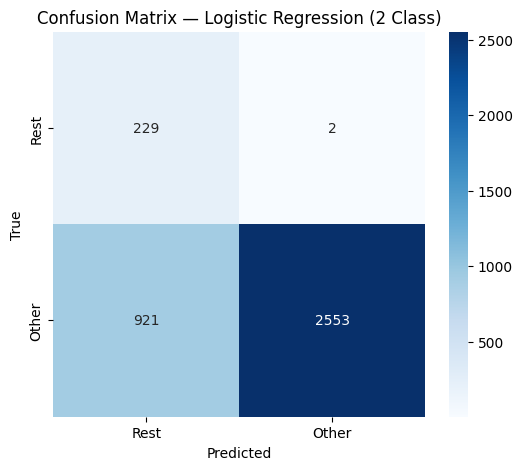

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rest", "Other"],
    yticklabels=["Rest", "Other"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Logistic Regression (2 Class)")
plt.show()


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [ ]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred_svm = svm_clf.predict(X_test_scaled)

accuracy_score(y_test,y_pred_svm)


0.7093117408906883

In [ ]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Rest", "Other"]
))

              precision    recall  f1-score   support

        Rest       0.18      0.99      0.30       231
       Other       1.00      0.69      0.82      3474

    accuracy                           0.71      3705
   macro avg       0.59      0.84      0.56      3705
weighted avg       0.95      0.71      0.78      3705



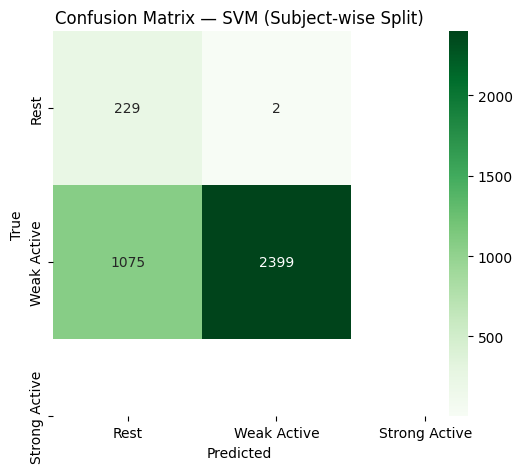

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — SVM (rest vs other)")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import accuracy_score
y_pred_rf = rf_clf.predict(X_test)

accuracy_score(y_test, y_pred_rf)

0.9373819163292848

In [ ]:
from sklearn.metrics import classification_report

# Use target names that match the two classes (0=Rest, 1=Other)
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Rest", "Other"],
    zero_division=0
))


              precision    recall  f1-score   support

        Rest       0.33      0.00      0.01       231
       Other       0.94      1.00      0.97      3474

    accuracy                           0.94      3705
   macro avg       0.64      0.50      0.49      3705
weighted avg       0.90      0.94      0.91      3705



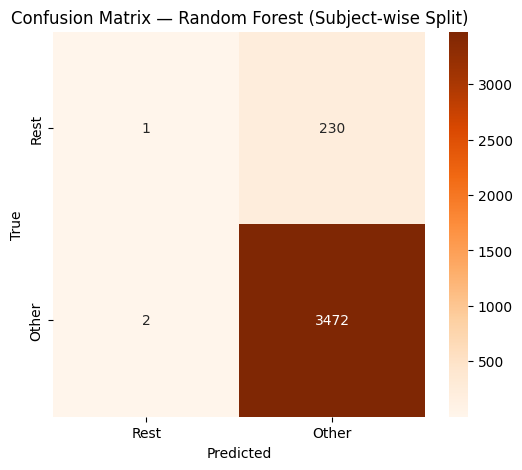

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Rest", "Other"],
    yticklabels=["Rest", "Other"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Random Forest (Subject-wise Split)")
plt.show()


In [64]:
import numpy as np

def compute_wl(window):
    """
    Waveform Length (WL)
    Sum of absolute differences between consecutive samples
    """
    return np.sum(np.abs(np.diff(window, axis=0)), axis=0)


def compute_zc(window, threshold=1e-5):
    """
    Zero Crossing (ZC)
    Counts sign changes with a small threshold to avoid noise
    """
    zc = []
    for ch in range(window.shape[1]):
        x = window[:, ch]
        zero_crossings = np.where(
            (x[:-1] * x[1:] < 0) &
            (np.abs(x[:-1] - x[1:]) >= threshold)
        )[0]
        zc.append(len(zero_crossings))
    return np.array(zc)


In [65]:
def extract_emg_features(X):
    features = []

    for window in X:
        rms = np.sqrt(np.mean(window**2, axis=0))
        mav = np.mean(np.abs(window), axis=0)
        wl  = compute_wl(window)
        zc  = compute_zc(window)

        # Concatenate all features
        feat = np.concatenate([rms, mav, wl, zc])
        features.append(feat)

    return np.array(features)


In [66]:
X_features_full = extract_emg_features(X_all)

X_features_full.shape


(68099, 32)

In [67]:
train_mask = np.isin(subjects_all, train_subjects)
test_mask  = np.isin(subjects_all, test_subjects)

X_train = X_features_full[train_mask]
y_train = y_all[train_mask]

X_test = X_features_full[test_mask]
y_test = y_all[test_mask]

X_train.shape, X_test.shape


((53180, 32), (14919, 32))

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [69]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)


              precision    recall  f1-score   support

        Rest       0.20      0.97      0.33       910
       Other       1.00      0.74      0.85     14009

    accuracy                           0.76     14919
   macro avg       0.60      0.86      0.59     14919
weighted avg       0.95      0.76      0.82     14919



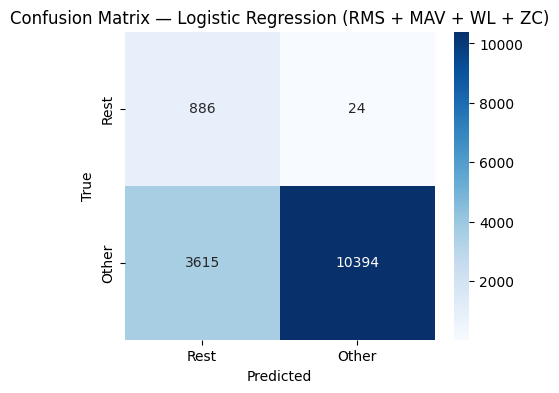

0.7560828473758294

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Rest", "Other"],
    zero_division=0
))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rest", "Other"],
    yticklabels=["Rest", "Other"]
)
plt.title("Confusion Matrix — Logistic Regression (RMS + MAV + WL + ZC)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

accuracy_score(y_test,y_pred_lr)

In [ ]:
from sklearn.svm import SVC

svm_new = SVC(
    kernel="rbf",
    C=1.0, gamma="scale",class_weight="balanced",random_state=42
)
svm_new.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_new = svm_new.predict(X_test_scaled)
accuracy_score(y_test, y_pred_new)

0.7290148448043184

In [ ]:
print(classification_report(
    y_test,
    y_pred_new,
    target_names=["Rest", "Other"]
))

              precision    recall  f1-score   support

        Rest       0.19      0.99      0.31       231
       Other       1.00      0.71      0.83      3474

    accuracy                           0.73      3705
   macro avg       0.59      0.85      0.57      3705
weighted avg       0.95      0.73      0.80      3705



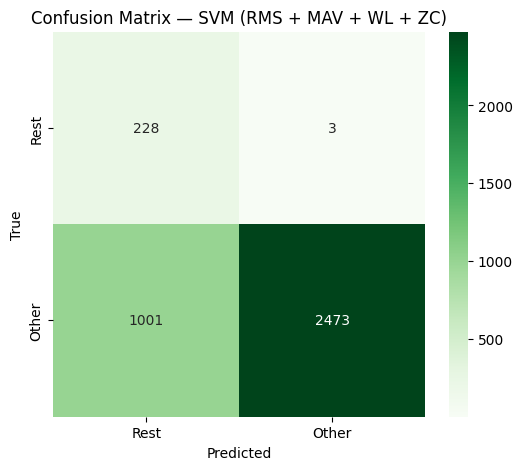

In [ ]:
cm_svm_new = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm_new,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rest", "Other"],
    yticklabels=["Rest", "Other"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — SVM (RMS + MAV + WL + ZC)")
plt.show()

In [ ]:
# Pick a random test index
idx = np.random.choice(np.where(test_mask)[0])

X_window = X_all[idx]              # shape (250, 8)
true_label = y_all[idx]
pred_label = svm_clf.predict(
    scaler.transform(X_features[idx].reshape(1, -1))
)[0]

true_label, pred_label


(np.int64(1), np.int64(0))

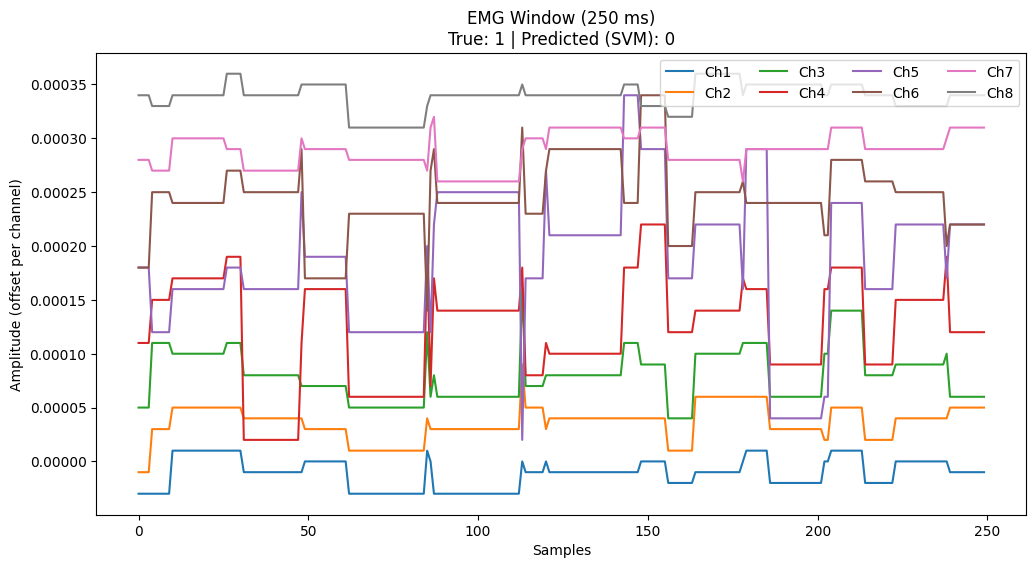

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for ch in range(8):
    plt.plot(
        X_window[:, ch] + ch * 5e-5,  # offset for visibility
        label=f"Ch{ch+1}"
    )

plt.title(
    f"EMG Window (250 ms)\nTrue: {true_label} | Predicted (SVM): {pred_label}"
)
plt.xlabel("Samples")
plt.ylabel("Amplitude (offset per channel)")
plt.legend(loc="upper right", ncol=4)
plt.show()


In [ ]:
# Pick a random test index
idx = np.random.choice(np.where(test_mask)[0])

X_window = X_all[idx]      # shape (250, 8)
true_label = y_all[idx]

# Random Forest prediction (NO scaling needed)
pred_label_rf = rf_clf.predict(
    X_features[idx].reshape(1, -1)
)[0]

true_label, pred_label_rf


array([0, 1])

In [ ]:
np.unique(y_all)


array([0, 1])

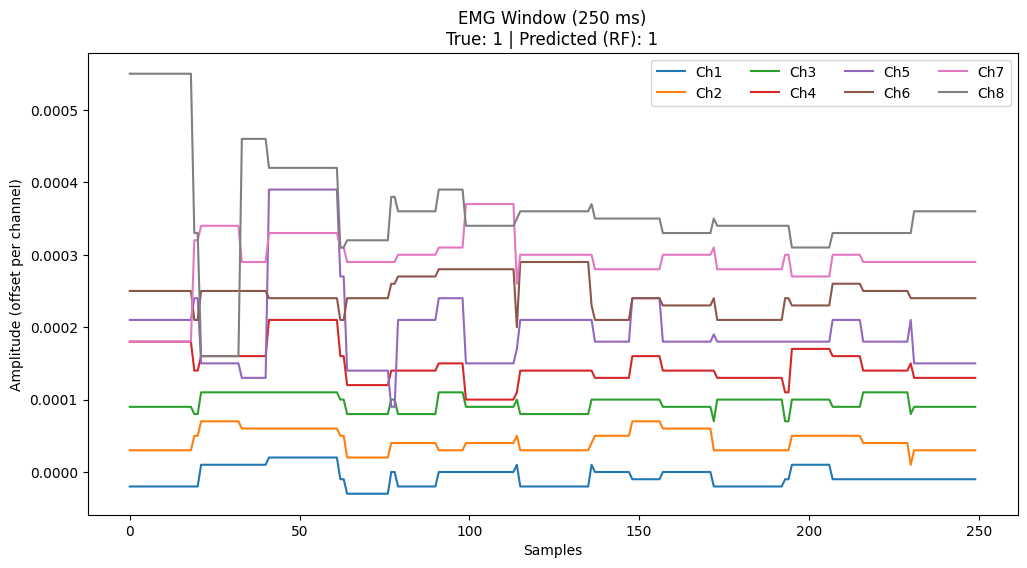

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for ch in range(8):
    plt.plot(
        X_window[:, ch] + ch * 5e-5,   # vertical offset per channel
        label=f"Ch{ch+1}"
    )

plt.title(
    f"EMG Window (250 ms)\nTrue: {true_label} | Predicted (RF): {pred_label_rf}"
)
plt.xlabel("Samples")
plt.ylabel("Amplitude (offset per channel)")
plt.legend(loc="upper right", ncol=4)
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
scaler_mlp = StandardScaler()

X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp  = scaler_mlp.transform(X_test)


In [ ]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # non-linear but simple
    activation="relu",
    solver="adam",
    alpha=1e-4,                    # L2 regularization
    max_iter=300,
    early_stopping=True,
    random_state=42
)


In [ ]:
mlp_clf.fit(X_train_mlp, y_train)


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [ ]:
y_pred_mlp = mlp_clf.predict(X_test_mlp)

accuracy_score(y_test, y_pred_mlp)


0.9376518218623482

In [ ]:
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=["Rest", "Other"],
    zero_division=0
))


              precision    recall  f1-score   support

        Rest       0.00      0.00      0.00       231
       Other       0.94      1.00      0.97      3474

    accuracy                           0.94      3705
   macro avg       0.47      0.50      0.48      3705
weighted avg       0.88      0.94      0.91      3705



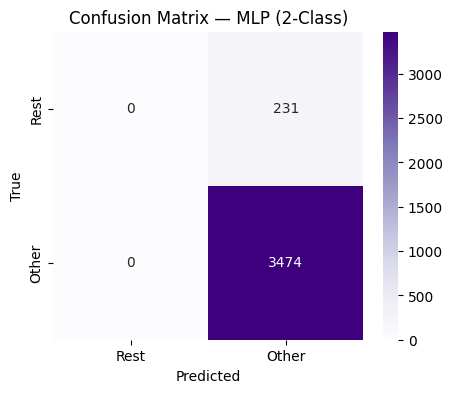

In [ ]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Rest", "Other"],
    yticklabels=["Rest", "Other"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — MLP (2-Class)")
plt.show()


In [ ]:
# CNN uses RAW windows (not features)
X_train_cnn = X_all[train_mask]
y_train_cnn = y_all[train_mask]

X_test_cnn = X_all[test_mask]
y_test_cnn = y_all[test_mask]

X_train_cnn.shape, X_test_cnn.shape


((13211, 250, 8), (3705, 250, 8))

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = 3

y_train_oh = to_categorical(y_train_cnn, num_classes)
y_test_oh = to_categorical(y_test_cnn, num_classes)

y_train_oh.shape


(13211, 3)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam


In [ ]:
cnn_model = Sequential([
    Conv1D(32, kernel_size=5, activation="relu", input_shape=(250, 8)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 246, 32)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 246, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 119, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 119, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       483,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,843 (1.89 MB)

 Trainable params: 495,651 (1.89 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_oh,
    validation_split=0.2,   # only within TRAIN subjects
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8823 - loss: 0.3258 - val_accuracy: 0.9417 - val_loss: 0.4274
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9386 - loss: 0.1671 - val_accuracy: 0.9417 - val_loss: 0.3304
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9393 - loss: 0.1612 - val_accuracy: 0.9417 - val_loss: 0.5384
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9419 - loss: 0.1577 - val_accuracy: 0.9417 - val_loss: 0.5865
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9387 - loss: 0.1572 - val_accuracy: 0.9417 - val_loss: 0.3039
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9401 - loss: 0.1538 - val_accuracy: 0.9417 - val_loss: 0.3824
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9393 - loss: 0.1510 - val_accuracy: 0.9417 - val_loss: 3.9497
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9396 - loss: 0.1471 - val_accu

In [ ]:
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_oh)
test_acc


116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9249 - loss: 17.9715


0.9376518130302429

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

print(classification_report(
    y_test_cnn,
    y_pred_cnn,
    target_names=["Rest", "Other"],
    zero_division=0
))


116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

        Rest       0.00      0.00      0.00       231
       Other       0.94      1.00      0.97      3474

    accuracy                           0.94      3705
   macro avg       0.47      0.50      0.48      3705
weighted avg       0.88      0.94      0.91      3705



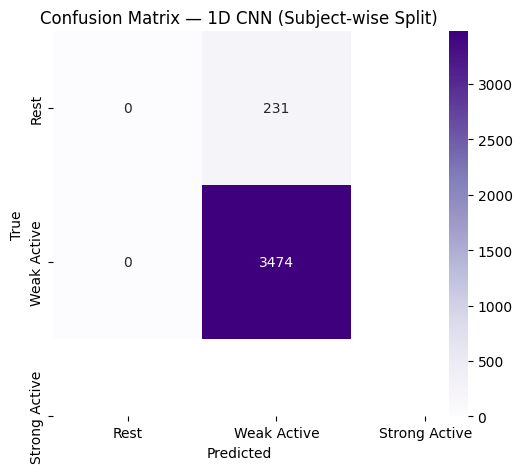

In [ ]:
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — 1D CNN (Subject-wise Split)")
plt.show()
